# Сравнение Байесовского и частотного подходов

Статья: https://habr.com/ru/companies/X5Tech/articles/900032/

TLTD: Можно просто использовать Частотный

In [11]:
import numpy as np 
import pandas as pd
from scipy import stats

import math

import matplotlib.pyplot as plt
import seaborn as sns
import random

from statsmodels.stats.power import tt_solve_power

from tqdm import tqdm

from statsmodels.graphics.gofplots import qqplot

from statsmodels.stats.proportion import proportion_confint, proportions_ztest

from collections import namedtuple, defaultdict

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 14
plt.rcParams['axes.titlesize'] = 21
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12

In [32]:
# Считаем размер выборки для Биноминального распределения
def get_sample_size(effect, p, alpha, beta):
    a = stats.norm().ppf(1 - alpha)
    b = stats.norm().ppf(1 - beta)
    p1 = p
    p2 = p + effect

    var = p1 * (1 - p1) + p2 * (1 - p2)

    n = np.ceil((var * (a + b) ** 2) / (effect ** 2))
    
    return int(n)

def frequency_test(sum_a, len_a, sum_b, len_b, alpha=0.05):
    pvalue = proportions_ztest([sum_a, len_a], [sum_b, len_b], alternative='smaller')[1]

    decision = int(pvalue < alpha)

    return pvalue, decision

def bayes_test(sum_a, len_a, sum_b, len_b, prior_a, prior_b, n=10000, alpha=0.05):
    posterior_a = [prior_a[0] + sum_a, prior_a[1] + len_a - sum_a]
    posterior_b = [prior_b[0] + sum_b, prior_b[1] + len_b - sum_b]
    values_a = stats.beta(*posterior_a).rvs(n)
    values_b = stats.beta(*posterior_b).rvs(n)

    prob_b_more = (values_b > values_a).mean()

    decision = int(prob_b_more > 1 - alpha)

    return 1 - prob_b_more, decision 

alpha = 0.05            
beta = 0.1                
p = 0.3       # исходная конверсия              
effect = 0.1    

# априорные распределения
prior_a = [1, 1]
prior_b = [1, 1]

sample_size = get_sample_size(effect, p, alpha, beta)

sample_size



386

In [26]:
def plot_pvalue_distribution(dict_pvalues):
    """Рисует графики распределения p-value."""
    X = np.linspace(0, 1, 1000)
    for name, pvalues in dict_pvalues.items():
        # Эмпирическая CDF для pvalue
        Y = [np.mean(pvalues < x) for x in X]
        plt.plot(X, Y, label=name)

    plt.plot([0, 1], [0, 1], '--k', alpha=0.8)
    plt.title('Оценка распределения p-value', size=16)
    plt.xlabel('p-value', size=12)
    plt.legend(fontsize=12)
    plt.grid()
    plt.show()

100%|██████████| 10000/10000 [00:21<00:00, 474.39it/s]


Freq A/A: pe=0.493, ci = [0.484, 0.503]
Freq A/B: pe=0.999, ci = [0.998, 1.000]
Bayes A/A: pe=0.051, ci = [0.046, 0.055]
Bayes A/B: pe=0.903, ci = [0.898, 0.909]


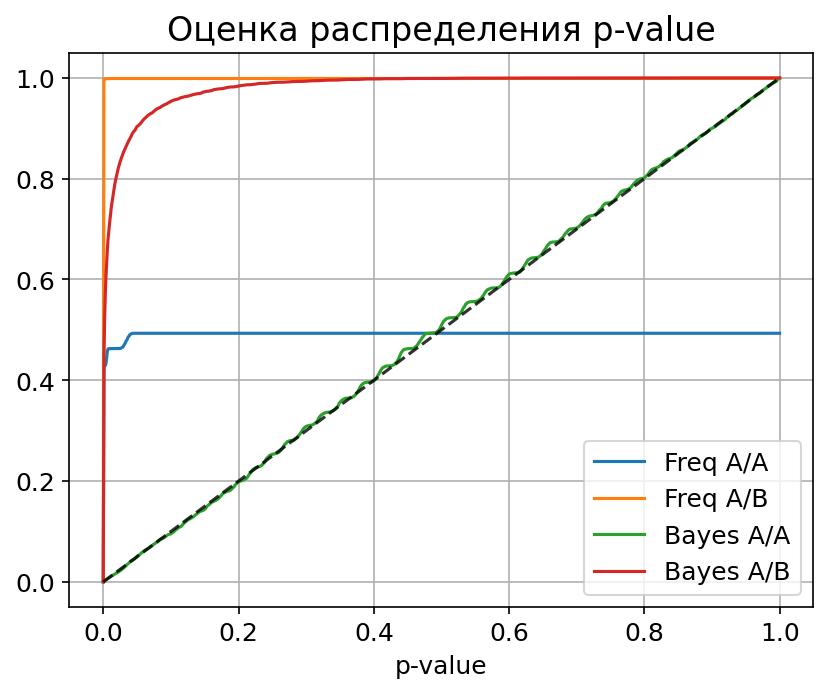

In [33]:
# Строим доверительные интервалы для decision
# Вопрос: верна ли гипотеза, что pvalue имеют нормальное распределение
def show_bernoulli_results(dict_decision):
    for key in dict_decision:
        values = dict_decision[key]
        pe = np.mean(values)
        std = np.std(values) / np.sqrt(len(values))

        ci_left, ci_right = pe - 1.96 * std, pe + 1.96 * std

        print(f"{key}: pe={pe:.3f}, ci = [{ci_left:.3f}, {ci_right:.3f}]")


dict_decision = defaultdict(list)
dict_pvalues = defaultdict(list)

# Monte Carlo
n_iter = 10000
for _ in tqdm(range(n_iter)):
    control = stats.binom(n=sample_size, p=p).rvs()
    test_aa = stats.binom(n=sample_size, p=p).rvs()
    test_ab = stats.binom(n=sample_size, p=p+effect).rvs()

    pvalue_freq_aa, decision_freq_aa = frequency_test(control, sample_size, test_aa, sample_size, alpha=alpha)
    pvalue_freq_ab, decision_freq_ab = frequency_test(control, sample_size, test_ab, sample_size, alpha=alpha)
    pvalue_bayes_aa, decision_bayes_aa = bayes_test(control, sample_size, test_aa, sample_size, prior_a, prior_b, alpha=alpha)
    pvalue_bayes_ab, decision_bayes_ab = bayes_test(control, sample_size, test_ab, sample_size, prior_a, prior_b, alpha=alpha)

    dict_decision["Freq A/A"].append(decision_freq_aa)
    dict_decision["Freq A/B"].append(decision_freq_ab)
    dict_decision["Bayes A/A"].append(decision_bayes_aa)
    dict_decision["Bayes A/B"].append(decision_bayes_ab)

    dict_pvalues["Freq A/A"].append(pvalue_freq_aa)
    dict_pvalues["Freq A/B"].append(pvalue_freq_ab)
    dict_pvalues["Bayes A/A"].append(pvalue_bayes_aa)
    dict_pvalues["Bayes A/B"].append(pvalue_bayes_ab)

show_bernoulli_results(dict_decision)

plot_pvalue_distribution(dict_pvalues)

In [ ]:
# Подглядывание 

# Останавливаем тест, если набрали больше 30 наблюдейний и получили decision
def bayes_seq_test(a, b, prior_a, prior_b):
    sum_a, len_a = prior_a
    sum_b, len_b = prior_b

    for a_value, b_value in zip(a, b):
        sum_a += a_value
        sum_b += b_value
        len_a += 1
        len_b += 1

        if len_a < 30:
            continue

        decision = bayes_test(sum_a, len_a, sum_b, len_b, prior_a, prior_b)[1]

        if decision:
            return 1
    
    return 0

def freq_seq_test(a, b):
    sum_a, len_a = 0, 0
    sum_b, len_b = 0, 0

    for a_value, b_value in zip(a, b):
        sum_a += a_value
        sum_b += b_value
        len_a += 1
        len_b += 1

        if len_a < 30:
            continue

        decision = frequency_test(sum_a, len_a, sum_b, len_b)[1]

        if decision:
            return 1
    
    return 0

# Делаем A/A тест

dict_decision = defaultdict(list)

p = 0.3
sample_size = 100
prior_a = [0.5, 0.5]
prior_b = [0.5, 0.5]

# Monte Carlo
n_iter = 100
for _ in tqdm(range(n_iter)):
    control = stats.bernoulli(p=p).rvs(sample_size)
    test_aa = stats.bernoulli(p=p).rvs(sample_size)

    decision_freq_aa = freq_seq_test(control, test_aa)
    decision_bayes_aa = bayes_seq_test(control, test_aa, prior_a, prior_b)

    dict_decision["Freq A/A"].append(decision_freq_aa)
    dict_decision["Bayes A/A"].append(decision_bayes_aa)

show_bernoulli_results(dict_decision)

100%|██████████| 100/100 [00:05<00:00, 18.52it/s]

Freq A/A: pe=0.780, ci = [0.699, 0.861]
Bayes A/A: pe=0.150, ci = [0.080, 0.220]


In [34]:
stats.bernoulli(p=p).rvs(sample_size)

array([1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,